In [69]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [70]:
(X_train,Y_train), (X_test,Y_test) = keras.datasets.mnist.load_data()#

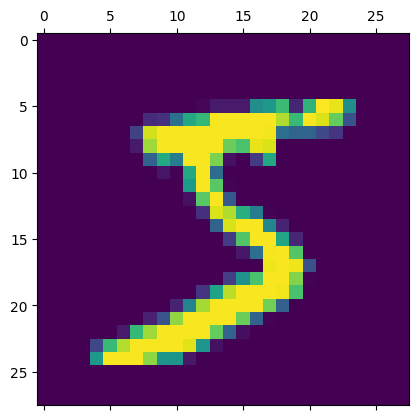

5


In [71]:
plt.matshow(X_train[0])
plt.show()
print(Y_train[0])

In [72]:
X_train_flat = X_train.reshape(len(X_train), 28*28)
X_test_flat = X_test.reshape(len(X_test), 28*28)

In [73]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(28*28,), activation ='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
#Optimizers allow you to train efficiently
#Loss function is sparse categorical crossentropy since our putput is categorical

model.fit(X_train_flat,Y_train, epochs=10) #Where training happens

Epoch 1/10


C:\Users\94701\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3063 - loss: 10.3356
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2977 - loss: 6.0096
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2905 - loss: 5.6537
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.2885 - loss: 5.4882
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.2837 - loss: 5.3718
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.2847 - loss: 5.2436
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.2749 - loss: 5.2968
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.2754 - loss: 5.2562
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.2675 - loss: 5.2411
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.2649 - loss: 5.1822


#### Not Accurate the reason can be we havent scalled the data  

In [74]:
X_train_flat = X_train_flat/255.0
X_test_flat = X_test_flat/255.0

In [75]:
model2 = keras.Sequential([
    keras.layers.Dense(10, input_shape=(28*28,), activation ='sigmoid')
])

model2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
#Optimizers allow you to train efficiently
#Loss function is sparse categorical crossentropy since our putput is categorical

model2.fit(X_train_flat,Y_train, epochs=5) #Where training happens

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8780 - loss: 0.4672
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9156 - loss: 0.3037
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9211 - loss: 0.2836
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9237 - loss: 0.2730
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9261 - loss: 0.2665


In [76]:
model2.evaluate(X_test_flat,Y_test) #Testing the model

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9253 - loss: 0.2701


[0.27005285024642944, 0.9253000020980835]

In [77]:
predicted=model2.predict(X_test_flat) #Predicting the model

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
# Predicted values (indices)
predictedVal = [int(np.argmax(i)) for i in predicted]


print(predictedVal[:5])
print(Y_test[:5])


[7, 2, 1, 0, 4]
[7 2 1 0 4]


In [88]:
cm = tf.math.confusion_matrix(labels=Y_test, predictions=predictedVal)


Text(95.72222222222221, 0.5, 'Truth')

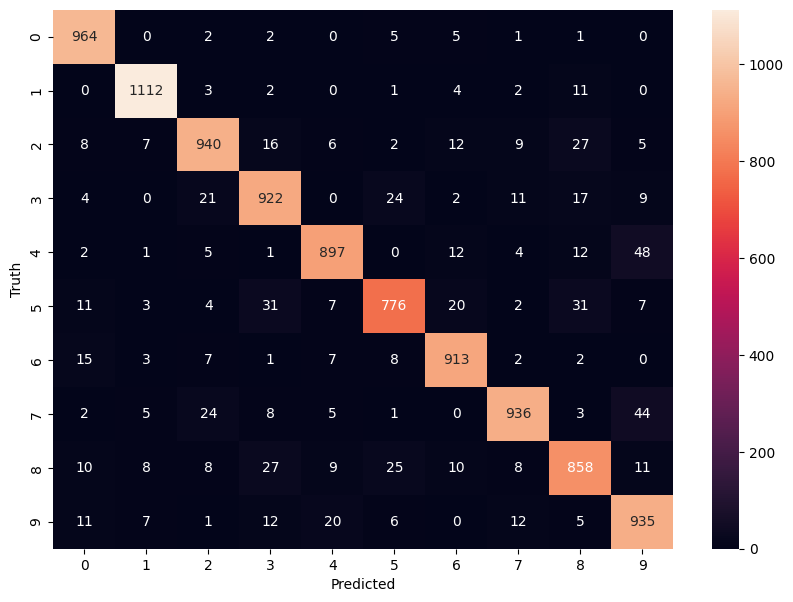

In [89]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d') 
plt.xlabel('Predicted')
plt.ylabel('Truth')


In [90]:
model3 = keras.Sequential([
    keras.layers.Dense(100, input_shape=(28*28,), activation ='relu'),
    keras.layers.Dense(10, activation ='sigmoid')
])

model3.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
#Optimizers allow you to train efficiently
#Loss function is sparse categorical crossentropy since our putput is categorical

model3.fit(X_train_flat,Y_train, epochs=5) #Where training happens

C:\Users\94701\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9230 - loss: 0.2714
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9624 - loss: 0.1268
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9732 - loss: 0.0891
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9789 - loss: 0.0680
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9837 - loss: 0.0538


In [91]:
model3.evaluate(X_test_flat,Y_test) #Testing the model

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9780 - loss: 0.0735


[0.07345513999462128, 0.9779999852180481]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[7, 2, 1, 0, 4]
[7 2 1 0 4]


Text(95.72222222222221, 0.5, 'Truth')

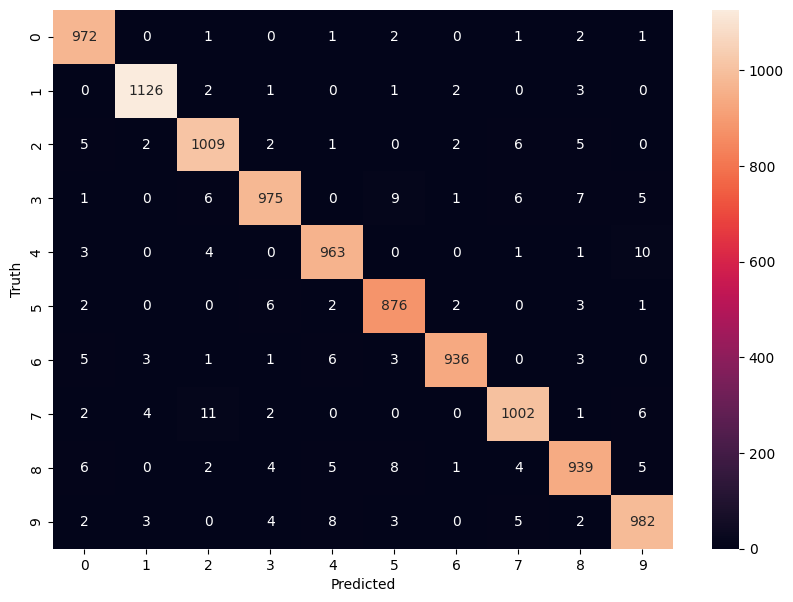

In [92]:
predicted=model3.predict(X_test_flat) #Predicting the model
# Predicted values (indices)
predictedVal = [int(np.argmax(i)) for i in predicted]


print(predictedVal[:5])
print(Y_test[:5])

cm = tf.math.confusion_matrix(labels=Y_test, predictions=predictedVal)

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d') 
plt.xlabel('Predicted')
plt.ylabel('Truth')


In [98]:
X_train = X_train/255.0
X_test = X_test/255.0

model4 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation ='relu'),
    keras.layers.Dense(10, activation ='sigmoid')
])

model4.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
#Optimizers allow you to train efficiently
#Loss function is sparse categorical crossentropy since our putput is categorical

model4.fit(X_train,Y_train, epochs=5) #Where training happens

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1119 - loss: 2.3014
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1124 - loss: 2.3010
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1124 - loss: 2.2999
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1137 - loss: 2.2971
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1303 - loss: 2.2905


In [99]:
model3.evaluate(X_test_flat,Y_test) #Testing the model

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9780 - loss: 0.0735


[0.07345513999462128, 0.9779999852180481]